# LDA / NMF / BERTopic 对照（K=5, 7）

在**同一 shared corpus** 上比较三种主题建模方法。

**语料规模**：当前 run 的 shared **28,055** 条，较 05-09 单批 run（18,832 条）约 **+49%**（两批合并 + 清洗规则微调）。

**标签注意**：`2026-05-19` run 产出时编码表仅覆盖第一批 16 帖，故 `config.json` 记录 **11,127** 条缺 `robot_status_group`。现表已补全第二批（列 `机器人状态`→`post_cate_robot`、`人的形象`→`post_cate_human`）。**读 run 内 `by_robot_status.csv` 或本 notebook 横切前，须用下方「标签重挂」格**；`混合` 帖不进分层；**`常态` 与 `中性` 为不同状态，不做别名替换**；历史 `成功|*` 标签已废弃，以编码表现行取值为准。分析用 **`human_role_group`**：服务者 / 抢救者 / 保护者 → **服务照护**（见 `phase1/post_category_labels.py`）。

**阅读顺序**：L1 主题词 → L1b Jaccard → **L1c 聚类质量指标** → L2 样本眼测 → L3 评论级对齐 → L4 UMAP → L5 K 灵敏度。

启动（仓库根目录）：

```

产物目录默认：`output/experiments/2026-05-19_topic_full_corpus_merged_bge_base/`。若该目录无产物，notebook 会自动改用本机已有的 `2026-05-27_topic_merged_bge_hdbscan_sensitivity`（shared **26,811** 条，与 `data/clean/shared_analyzable_corpus.csv` 一致）。换 run 只改下面 `RUN_ID`。

In [1]:
# 0) 路径与配置
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation, NMF, PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "phase1" / "topic_modeling.py").exists()),
    _cwd,
)
if PROJECT_ROOT != _cwd:
    os.chdir(PROJECT_ROOT)

RUN_ID = "2026-05-27_topic_merged_bge_hdbscan_sensitivity"


def _experiment_dir(run_id: str) -> Path:
    return PROJECT_ROOT / "output" / "experiments" / run_id


def resolve_run_dir(preferred_run_id: str) -> tuple[str, Path]:
    preferred = _experiment_dir(preferred_run_id)
    preferred.mkdir(parents=True, exist_ok=True)
    if (preferred / "shared_analyzable_corpus.csv").is_file():
        return preferred_run_id, preferred
    fallback = _experiment_dir(_FALLBACK_RUN_ID)
    if fallback.is_dir() and (fallback / "shared_analyzable_corpus.csv").is_file():
        print(f"[WARN] {preferred_run_id} 无实验产物，改用 {_FALLBACK_RUN_ID}")
        return _FALLBACK_RUN_ID, fallback
    return preferred_run_id, preferred


RUN_ID, RUN_DIR = resolve_run_dir(RUN_ID)
K_LIST = [5, 7]

SHARED_CORPUS_CANDIDATES = [
    RUN_DIR / "shared_analyzable_corpus.csv",
    PROJECT_ROOT / "data" / "clean" / "shared_analyzable_corpus.csv",
]


def resolve_shared_corpus_path() -> Path:
    for p in SHARED_CORPUS_CANDIDATES:
        if p.is_file():
            return p
    raise FileNotFoundError(
        "找不到 shared_analyzable_corpus.csv；请运行 "
        "`./.venv/bin/python -m phase1.topic_modeling --run-id <RUN_ID>` "
        f"或 `python -m tools.export_shared_analyzable_corpus`。已查找: {SHARED_CORPUS_CANDIDATES}"
    )


SHARED_CORPUS_PATH = resolve_shared_corpus_path()
assert RUN_DIR.is_dir(), f"找不到实验目录: {RUN_DIR}"
print("ROOT =", PROJECT_ROOT)
print("RUN  =", RUN_DIR)
print("SHARED =", SHARED_CORPUS_PATH)

ROOT = /Users/yilin/project/2604-robotic_failure_research
RUN  = /Users/yilin/project/2604-robotic_failure_research/output/experiments/2026-05-27_topic_merged_bge_hdbscan_sensitivity
SHARED = /Users/yilin/project/2604-robotic_failure_research/output/experiments/2026-05-27_topic_merged_bge_hdbscan_sensitivity/shared_analyzable_corpus.csv


In [2]:
# 工具函数（改 phase1 源码后 reload 即可，不必重启内核）
import importlib

import phase1.post_category_labels as _post_category_labels

importlib.reload(_post_category_labels)
from phase1.post_category_labels import (
    HUMAN_ROLE_MERGE_RULE,
    human_role_to_analysis_group,
    load_post_category_by_post,
)
from phase1.topic_lda import load_topic_stopwords
from phase1.topic_modeling import TopicModelingConfig, _space_join_tokens, robot_status_to_stratum_group

CFG = TopicModelingConfig(run_id=RUN_ID)
STOPWORDS = load_topic_stopwords()

_LABEL_COLS = [
    "comment_id",
    "content",
    "robot_status",
    "human_role",
    "post_cate_robot",
    "post_cate_human",
    "human_role_group",
    "robot_status_group",
    "post_category",
    "comment_level",
]


def load_topics(method: str, k: int) -> pd.DataFrame:
    """统一为列 topic, top_terms, size（BERTopic 原始列为 Topic/Count/Representation）。"""
    import ast

    if method == "bert":
        path = RUN_DIR / f"bert_kmeans_k{k}" / "topics.csv"
    else:
        path = RUN_DIR / f"{method}_k{k}_topics.csv"
    df = pd.read_csv(path)

    if method == "bert":
        df = df.rename(columns={"Topic": "topic", "Count": "size"})
        if "top_terms" not in df.columns:
            if "Representation" in df.columns:

                def _rep_to_terms(s: str) -> str:
                    try:
                        words = ast.literal_eval(str(s))
                        if isinstance(words, list):
                            return ", ".join(str(w) for w in words[:15])
                    except (ValueError, SyntaxError):
                        pass
                    return str(s)

                df["top_terms"] = df["Representation"].map(_rep_to_terms)
            elif "Name" in df.columns:
                df["top_terms"] = df["Name"].astype(str).str.replace(r"^\d+_", "", regex=True).str.replace("_", ", ")
    df["method"] = method
    for col in ("topic", "top_terms", "size"):
        if col not in df.columns:
            raise KeyError(f"{path.name} 缺少列 {col!r}，现有: {list(df.columns)}")
    return df


def load_samples(method: str, k: int) -> pd.DataFrame:
    if method == "bert":
        path = RUN_DIR / f"bert_kmeans_k{k}" / "samples.csv"
    else:
        path = RUN_DIR / f"{method}_k{k}_samples.csv"
    return pd.read_csv(path)


def load_bert_doc_topics(k: int) -> pd.DataFrame:
    df = pd.read_csv(RUN_DIR / f"bert_kmeans_k{k}" / "doc_topics.csv")
    return df[["comment_id", "topic"]].rename(columns={"topic": f"topic_bert_k{k}"})


def jaccard_terms(a: str, b: str) -> float:
    sa = {x.strip() for x in str(a).split(",") if x.strip()}
    sb = {x.strip() for x in str(b).split(",") if x.strip()}
    if not sa and not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


def fit_lda_nmf_labels(shared: pd.DataFrame, k: int) -> pd.DataFrame:
    """与 topic_modeling.py 相同参数，返回全量 comment_id → topic_lda / topic_nmf。"""
    doc_joined = [_space_join_tokens(t, STOPWORDS) for t in shared["content"].astype(str)]

    vec_lda = CountVectorizer(
        analyzer=lambda s: s.split(),
        min_df=CFG.lda_min_df,
        max_df=CFG.lda_max_df,
        max_features=CFG.max_features,
    )
    X_lda = vec_lda.fit_transform(doc_joined)
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="batch",
        max_iter=40,
        random_state=CFG.random_seed,
        doc_topic_prior=1.0 / k,
        topic_word_prior=0.01,
    )
    dt_lda = lda.fit_transform(X_lda)

    vec_nmf = TfidfVectorizer(
        analyzer=lambda s: s.split(),
        min_df=CFG.nmf_min_df,
        max_df=CFG.nmf_max_df,
        max_features=CFG.max_features,
    )
    X_nmf = vec_nmf.fit_transform(doc_joined)
    nmf = NMF(n_components=k, init="nndsvda", random_state=CFG.random_seed, max_iter=400)
    W = nmf.fit_transform(X_nmf)

    cols = [c for c in _LABEL_COLS if c in shared.columns]
    out = shared[cols].copy()
    out[f"topic_lda_k{k}"] = dt_lda.argmax(axis=1)
    out[f"topic_nmf_k{k}"] = W.argmax(axis=1)
    out[f"prob_lda_k{k}"] = dt_lda.max(axis=1)
    out[f"prob_nmf_k{k}"] = W.max(axis=1)
    return out


def topic_jaccard_matrix(method_a: str, method_b: str, k: int) -> pd.DataFrame:
    ta = load_topics(method_a, k).set_index("topic")["top_terms"]
    tb = load_topics(method_b, k).set_index("topic")["top_terms"]
    mat = pd.DataFrame(index=ta.index, columns=tb.index, dtype=float)
    for i in ta.index:
        for j in tb.index:
            mat.loc[i, j] = jaccard_terms(ta[i], tb[j])
    mat.index = [f"{method_a}_{i}" for i in mat.index]
    mat.columns = [f"{method_b}_{j}" for j in mat.columns]
    return mat


def agreement_table(df: pd.DataFrame, col_a: str, col_b: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "pair": f"{col_a} vs {col_b}",
            "ARI": adjusted_rand_score(df[col_a], df[col_b]),
            "NMI": normalized_mutual_info_score(df[col_a], df[col_b]),
        },
        index=[0],
    )


shared = pd.read_csv(SHARED_CORPUS_PATH)
print(f"shared corpus: {len(shared):,} 条（来源: {SHARED_CORPUS_PATH.name}；05-09 单批 baseline: 18,832）")

# 标签重挂：run 内 robot_status 可能过时，以当前 config 为准
_post_labels = load_post_category_by_post(CFG.post_category_by_post_csv)
shared = shared.drop(
    columns=[
        "robot_status",
        "human_role",
        "post_category",
        "robot_status_group",
        "human_role_group",
    ],
    errors="ignore",
)
shared = shared.merge(_post_labels, on="帖子id", how="left")
shared["robot_status_group"] = shared["robot_status"].map(robot_status_to_stratum_group)
shared["human_role_group"] = shared["post_cate_human"].map(human_role_to_analysis_group)

_n_miss = int(shared["robot_status_group"].isna().sum())
_n_mix = int((shared["post_cate_robot"] == "混合").sum())
print(f"robot_status_group 缺失: {_n_miss:,}（含混合帖 {_n_mix:,} 条，不参与分层）")
print("post_cate_robot:\n", shared["post_cate_robot"].value_counts().to_string())
print(f"\nhuman_role 合并规则: {HUMAN_ROLE_MERGE_RULE}")
print("human_role_group:\n", shared["human_role_group"].value_counts().to_string())
print("\n=== 机器人状态 × 人的形象（分析合并后）===")
print(
    pd.crosstab(
        shared["post_cate_robot"],
        shared["human_role_group"],
        margins=True,
        margins_name="合计",
    ).to_string()
)

shared corpus: 26,811 条（来源: shared_analyzable_corpus.csv；05-09 单批 baseline: 18,832）
robot_status_group 缺失: 3,756（含混合帖 3,756 条，不参与分层）
post_cate_robot:
 post_cate_robot
强势    14832
混合     3756
弱势     3406
失败     2845
常态     1972

human_role 合并规则: 服务者、抢救者、保护者 → 服务照护；被超越者、观众保持原标签。
human_role_group:
 human_role_group
观众      14027
服务照护    12313
被超越者      471

=== 机器人状态 × 人的形象（分析合并后）===
human_role_group   服务照护  被超越者     观众     合计
post_cate_robot                            
失败                 1597     0   1248   2845
常态                 1160     0    812   1972
弱势                  951     0   2455   3406
强势                 8605   471   5756  14832
混合                    0     0   3756   3756
合计                12313   471  14027  26811


/Users/yilin/project/2604-robotic_failure_research/.venv/lib/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## L1 · 主题词浏览（**非** topic 编号一一对照）

同一 K 下，**分别**看三方法各自的主题词与簇大小（**topic 编号不可横比**）。

| 列 | 作用 |
|----|------|
| **词1–5** / **词6–15** | 前段 vs 后段；专有话语常在 6–15 出现 |
| **junk / junk词** | 对**全部 15 词**扫泛词，不是只看前 5 |


In [3]:
import re

from IPython.display import display

JUNK_HEAD = frozenset({"机器人", "这个", "那个", "有人", "东西", "玩意", "评论", "知道", "好像", "真的"})
PIPELINE_TOP_N = 15  # 与 phase1/topic_modeling.py top_terms 一致；CSV 里没有第 16–20 个词


def parse_top_terms(s: str) -> list[str]:
    return [p.strip() for p in re.split(r",\s*", str(s).strip()) if p.strip()]


def junk_scan(terms: list[str]) -> tuple[str, str]:
    """在全部 top 词（最多 15）上扫 JUNK_HEAD；返回 (junk 标签, junk 词串)。"""
    hits = [w for w in terms if w in JUNK_HEAD]
    if not hits:
        return "", "—"
    words = ", ".join(hits)
    if len(hits) >= 3:
        return "⚠杂物桶", words
    if len(hits) >= 2:
        return "泛词偏多", words
    return "", words


def show_topics_l1(k: int, *, head_n: int = 5, tail_from: int = 6, tail_to: int = PIPELINE_TOP_N) -> None:
    """分方法展示；用「前段/后段」代替 top5 与完整 top_terms 叠在一起。"""
    print(f"\n{'='*60}\nK = {k}  （编号不可横比；每主题最多 {PIPELINE_TOP_N} 词）\n{'='*60}")
    for method in ["lda", "nmf", "bert"]:
        t = load_topics(method, k).copy()
        total = t["size"].sum()
        t["size_pct"] = (t["size"] / total * 100).round(1)
        lists = t["top_terms"].map(parse_top_terms)
        t[f"词1–{head_n}"] = lists.map(lambda xs: ", ".join(xs[:head_n]) if xs else "—")
        t[f"词{tail_from}–{tail_to}"] = lists.map(
            lambda xs: ", ".join(xs[tail_from - 1 : tail_to]) if len(xs) >= tail_from else "—"
        )
        junk = lists.map(junk_scan)
        t["junk"] = junk.map(lambda x: x[0])
        t["junk词"] = junk.map(lambda x: x[1])
        cols = ["topic", "size", "size_pct", "junk", "junk词", f"词1–{head_n}", f"词{tail_from}–{tail_to}"]
        print(f"\n--- {method.upper()} k={k} | 最大簇 {t['size_pct'].max():.1f}% ---")
        display(t[cols])


for k in K_LIST:
    show_topics_l1(k)


K = 5  （编号不可横比；每主题最多 15 词）

--- LDA k=5 | 最大簇 22.9% ---


,topic,size,size_pct,junk,junk词,词1–5,词6–15
0,0,5764,21.5,⚠杂物桶,"机器人, 知道, 东西","机器人, 意义, 知道, 发展, 人","这样, 马拉松, 以为, 人类, 科技, 人家, 加油, ai, 东西, 中国"
1,1,4144,15.5,泛词偏多,"机器人, 评论","机器人, 比赛, 技术, 马拉松, 测试","问题, 人形机器人, 电池, 参加, 评论, 只是, 地形, 复杂, 能力, 续航"
2,2,4650,17.3,泛词偏多,"机器人, 真的","人, 机器人, 遥控, 自主, 真的","需要, 三个, 玩具, 战场, 要是, 补给, 容易, 伺候, 控制, 跟着"
3,3,6132,22.9,,—,"可爱, 降温, 后面, 起来, 最后","去年, 程序员, 孩子, 搞笑, 厉害, 跟着, 遥控器, 冰块, 是不是, 进步"
4,4,6121,22.8,,机器人,"机器人, 跑步, 人类, 轮子, 人","机器, 人形, 为什么, 设计, 为了, 汽车, 服务, 外卖, 一样, 散热"



--- NMF k=5 | 最大簇 51.8% ---


,topic,size,size_pct,junk,junk词,词1–5,词6–15
0,0,5470,20.4,,机器人,"机器人, 服务, 这些, 人类, 为什么","加油, 外卖, 伺候, 是不是, 人形, 发展, 以为, 三个, 需要, 低血糖"
1,1,2846,10.6,,—,"人, 跟着, 机器, 三个, 伺候","需要, 后面, 一样, 服务, 遥控器, 控制, 最后, 一起, 機器, 很多"
2,2,1965,7.3,,有人,"遥控, 自主, 玩具, 跟着, 后面","遥控器, 还要, 赛车, 导航, 控制, 今年, 两个, 区别, 而已, 有人"
3,3,2631,9.8,泛词偏多,"真的, 东西","可爱, 真的, 奶瓶, 小小的, 搞笑","小黑, 宝宝, 小鼻嘎, 东西, 小孩, 小机器人, 起来, 解说, 最后, 果然"
4,4,13899,51.8,,知道,"马拉松, 意义, 跑步, 比赛, 轮子","人类, 为什么, 降温, 赛车, 汽车, 程序员, 人形机器人, 参加, 知道, 姿势"



--- BERT k=5 | 最大簇 27.0% ---


...

,topic,size,size_pct,junk,junk词,词1–5,词6–15
0,0,4300,16.0,⚠杂物桶,"机器人, 知道, 东西, 玩意","机器人, 发展, 知道, 人, 意义","ai, 人类, 东西, 科技, 这样, 中国, 加油, 玩意, 未来, 工作"
1,1,2917,10.9,泛词偏多,"机器人, 评论","机器人, 技术, 测试, 问题, 评论","比赛, 马拉松, 参加, 只是, 摔倒, 能力, 视频, 为了, 之后, 平衡"
2,2,3744,14.0,,机器人,"人, 机器人, 遥控, 自主, 跟着","遥控器, 需要, 三个, 玩具, 战场, 后面, 补给, 工作人员, 伺候, 控制"
3,3,3865,14.4,泛词偏多,"真的, 好像","真的, 进步, 好像, 去年, 孩子","一下, 厉害, 可爱, 赛车, 今年, 看着, 地上, 不行, f1, 样子"
4,4,4231,15.8,,机器人,"机器人, 人类, 人, 机器, 人形","马拉松, 设计, 为了, 服务, 外卖, 意义, 需要, 地形, 人形机器人, 个人"
5,5,3921,14.6,,—,"降温, 程序员, 最后, 以为, 可爱","散热, 后面, 电池, 冰块, 两个, 关节, 工程师, 还要, 搞笑, 喜欢"
6,6,3833,14.3,,机器人,"机器人, 跑步, 比赛, 轮子, 为什么","汽车, 一样, 荣耀, 速度, 更快, 姿势, 人类, 马拉松, 低血糖, 一定"



--- NMF k=7 | 最大簇 36.4% ---


,topic,size,size_pct,junk,junk词,词1–5,词6–15
0,0,5107,19.0,,机器人,"机器人, 人类, 服务, 这些, 为什么","加油, 外卖, 伺候, 是不是, 人形, 发展, 需要, 以为, 三个, 个人"
1,1,2705,10.1,,—,"人, 跟着, 机器, 三个, 伺候","需要, 后面, 一样, 服务, 遥控器, 控制, 最后, 一起, 機器, 很多"
2,2,1724,6.4,,有人,"遥控, 自主, 玩具, 跟着, 后面","遥控器, 还要, 导航, 赛车, 控制, 今年, 两个, 区别, 而已, 有人"
3,3,2434,9.1,泛词偏多,"真的, 东西","可爱, 真的, 奶瓶, 小小的, 搞笑","小黑, 宝宝, 小鼻嘎, 东西, 小孩, 小机器人, 起来, 解说, 最后, 果然"
4,4,2691,10.0,泛词偏多,"东西, 知道","马拉松, 意义, 人类, 程序员, 参加","比赛, 哪里, 何在, 需要, 东西, 知道, 机器人马拉松, 去年, 人形机器人, 测试"
5,5,2386,8.9,,—,"降温, 冰块, 润滑, 散热, 干冰","喷雾, 关节, 还要, 电池, 换电池, 后面, 电机, 需要, 加冰, 物理"
6,6,9764,36.4,,知道,"跑步, 比赛, 轮子, 为什么, 赛车","姿势, 人类, 汽车, 一样, 人形, 人形机器人, 为了, 更快, 知道, 这样"



--- BERT k=7 | 最大簇 24.1% ---


,topic,size,size_pct,junk,junk词,词1–5,词6–15
0,0,6467,24.1,,机器人,"机器人, 小机器人, 人形机器人, 机器狗, 机器人马拉松","机器, 搞笑, 机械, 比赛, 人形"
1,1,4801,17.9,,—,"跑不过, 跑得快, 跑不动, 跑步, 马拉松","挺快, 追不上, 跟着, 站不稳, 后面"
2,2,4779,17.8,,有人,"今年, 去年, 科技进步, 进步, 有人","一年, 很多, 越来越, 很快, 以前"
3,3,3735,13.9,,—,"好笑, 可爱, 好好笑, 好玩, 搞笑","有趣, 幽默, 好看, 有意思, 喜欢"
4,4,2815,10.5,,玩意,"轮子, 轮胎, 赛车, 汽车, 轮椅","玩意, 开车, 机器, 轱辘, 摩托车"
5,5,2319,8.6,,—,"降温, 加冰, 冰块, 冷却, 发热","过热, 高温, 温度, 散热, 制冷"
6,6,1895,7.1,,有人,"遥控, 遥控器, 遥控车, 操控, 自主","自动, 跟不上, 控制, 有人, 全自动"


## L1b · 主题词 Jaccard 热图

topic id **不可直接对齐**；Jaccard 找「词面最近邻」。亮块 = 两方法在命名上接近。

/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yilin/project/260

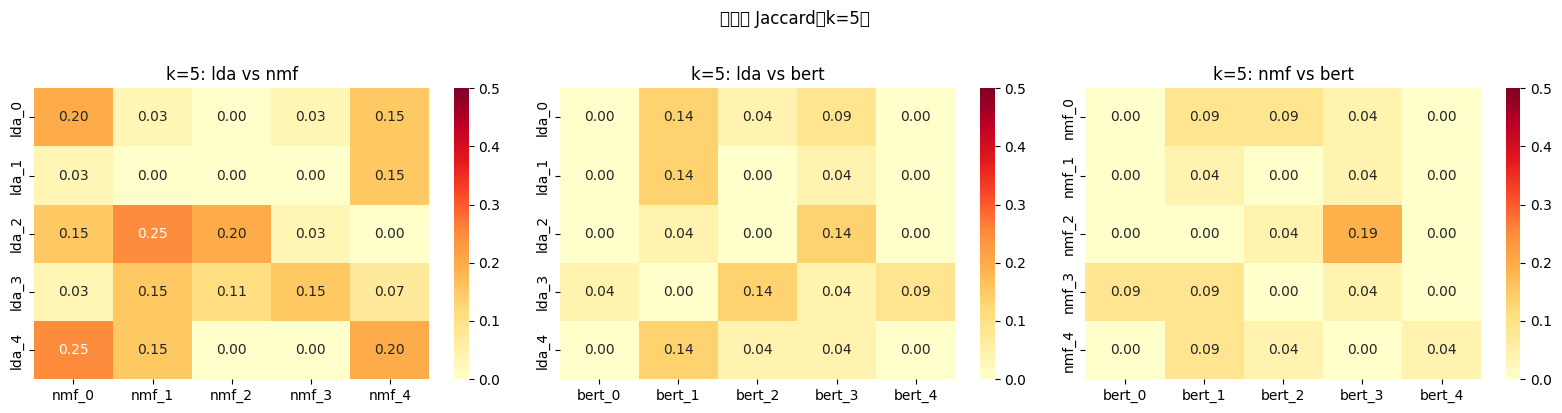

/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_88535/2548469140.py:9: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yilin/project/260

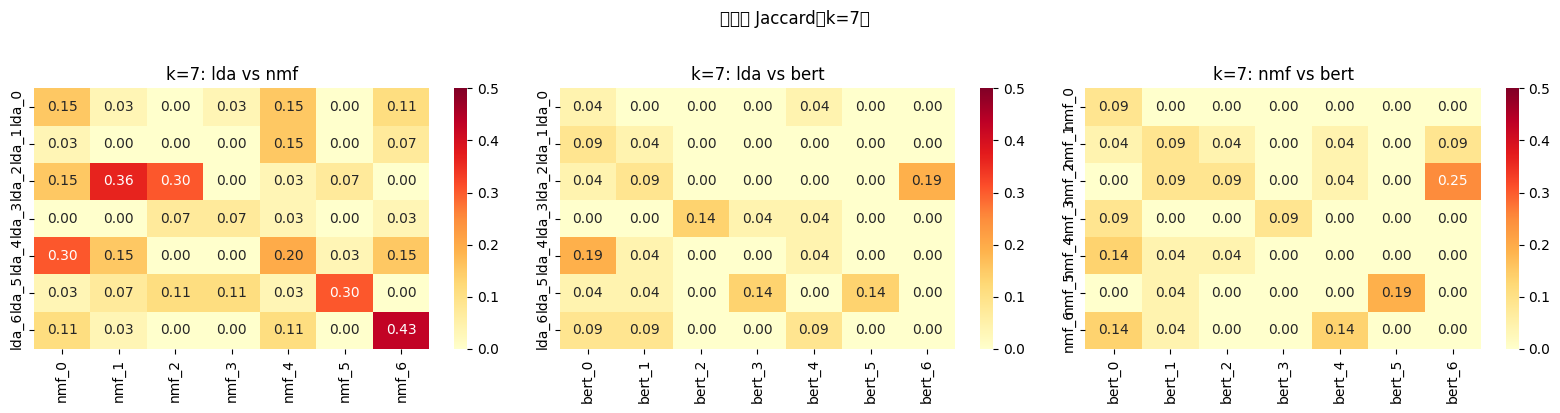

In [4]:
for k in K_LIST:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    pairs = [("lda", "nmf"), ("lda", "bert"), ("nmf", "bert")]
    for ax, (a, b) in zip(axes, pairs):
        mat = topic_jaccard_matrix(a, b, k)
        sns.heatmap(mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, vmin=0, vmax=0.5)
        ax.set_title(f"k={k}: {a} vs {b}")
    plt.suptitle(f"主题词 Jaccard（k={k}）", y=1.02)
    plt.tight_layout()
    plt.show()

## L1c · 聚类质量指标（除最大簇占比外）

**两类指标，不要混读：**

| 类型 | 含义 | 适用 |
|------|------|------|
| **A. 管线已落盘** | 训练时就算好，见 `a_lda_nmf_k_selection.csv` / `a_bertopic_quality.csv` | 与当时 fit 一致 |
| **B. 由主题 `size` 推导** | 簇大小是否均衡（熵、Gini、≥1% 的有效主题数） | 三方法可比 |
| **C. 同一 UMAP 上的几何指标** | 在 **BERTopic 共用的 5D UMAP** 上，用各方法的**标签**算 silhouette / Davies–Bouldin / Calinski–Harabasz | 比较「分簇在嵌入空间里是否分得开」；**需先跑 L3** |
| **D. 软分配置信度** | LDA/NMF 的 `topic_prob` 均值/分位数 | 仅 LDA/NMF；**需先跑 L3** |

**不当作「聚类质量」的：** `topic_prob` 高 ≠ 主题有理论意义；perplexity 在短文本上常随 K 单调，仅作方法内灵敏度参考。

In [14]:
def balance_metrics_from_sizes(sizes: np.ndarray) -> dict:
    """由每主题文档数计算簇大小均衡类指标（与具体向量空间无关）。"""
    sizes = np.asarray(sizes, dtype=float)
    total = sizes.sum()
    if total <= 0 or len(sizes) == 0:
        return {}
    p = sizes / total
    k = len(sizes)
    # Gini: 0=完全均衡, 1=极端集中
    sorted_s = np.sort(sizes)
    n = len(sorted_s)
    gini = float((2 * np.arange(1, n + 1) - n - 1) @ sorted_s / (n * total))
    ent = float(-np.sum(p[p > 0] * np.log(p[p > 0])))
    ent_norm = float(ent / np.log(k)) if k > 1 else 1.0
    return {
        "n_topics": k,
        "n_docs": int(total),
        "largest_share": float(p.max()),
        "smallest_share": float(p.min()),
        "size_entropy": ent,
        "size_entropy_norm": ent_norm,
        "gini_size": gini,
        "imbalance_ratio": float(sizes.max() / sizes.min()) if sizes.min() > 0 else np.inf,
        "n_topics_ge_1pct": int((p >= 0.01).sum()),
        "n_topics_ge_50docs": int((sizes >= 50).sum()),
    }


def geometry_cluster_metrics(reduced: np.ndarray, labels: np.ndarray) -> dict:
    """在固定嵌入/降维空间上评价标签的几何可分性（如 5D UMAP）。"""
    from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

    labels = np.asarray(labels)
    mask = labels != -1
    lab = labels[mask]
    X = np.asarray(reduced)[mask]
    n_cls = len(set(lab.tolist()))
    out = {"n_labeled": int(mask.sum()), "n_clusters": n_cls}
    if n_cls < 2 or len(lab) < 3:
        out.update(silhouette=np.nan, davies_bouldin=np.nan, calinski_harabasz=np.nan)
        return out
    out["silhouette"] = float(silhouette_score(X, lab))
    out["davies_bouldin"] = float(davies_bouldin_score(X, lab))
    out["calinski_harabasz"] = float(calinski_harabasz_score(X, lab))
    return out


# --- A. 管线已保存的指标 ---
lda_nmf_sel = pd.read_csv(RUN_DIR / "a_lda_nmf_k_selection.csv")
lda_nmf_sel = lda_nmf_sel[lda_nmf_sel["k"].isin(K_LIST)].copy()
bert_q = pd.read_csv(RUN_DIR / "a_bertopic_quality.csv")
bert_km = bert_q[(bert_q["method"] == "kmeans") & (bert_q["k_or_mcs"].isin(K_LIST))].copy()

print("=== A1. LDA / NMF（管线）===\n")
display(
    lda_nmf_sel[
        [
            "method",
            "k",
            "perplexity",
            "reconstruction_err",
            "topic_diversity",
            "largest_topic_share",
            "smallest_topic_share",
        ]
    ].round(4)
)

print("\n=== A2. BERTopic KMeans（管线，silhouette 在 5D UMAP 上）===\n")
display(
    bert_km[
        [
            "k_or_mcs",
            "n_topics",
            "silhouette",
            "mean_ari",
            "min_ari",
            "largest_share",
            "smallest_share",
        ]
    ].round(4)
)

# --- B. 由 topics.csv 的 size 列推导（三方法统一）---
balance_rows = []
for k in K_LIST:
    for method in ["lda", "nmf", "bert"]:
        sizes = load_topics(method, k)["size"].to_numpy()
        row = balance_metrics_from_sizes(sizes)
        row.update(method=method, k=k)
        balance_rows.append(row)

balance_df = pd.DataFrame(balance_rows)
metric_cols = [
    "method",
    "k",
    "largest_share",
    "smallest_share",
    "size_entropy_norm",
    "gini_size",
    "imbalance_ratio",
    "n_topics_ge_1pct",
    "n_topics_ge_50docs",
]
print("\n=== B. 簇大小均衡（由 size 推导；entropy_norm∈[0,1] 越大越均衡）===\n")
display(balance_df[metric_cols].round(4))

# BERT 多 seed 稳定性（若存在）
for k in K_LIST:
    p = RUN_DIR / f"bert_kmeans_k{k}" / "stability_seeds.csv"
    if p.is_file():
        print(f"\nBERT k={k} stability_seeds:\n", pd.read_csv(p).to_string(index=False))

=== A1. LDA / NMF（管线）===



,method,k,perplexity,reconstruction_err,topic_diversity,largest_topic_share,smallest_topic_share
0,lda,5,1736.2850,NaN,0.9717,0.2188,0.1852
1,lda,7,1748.6828,NaN,0.9542,0.1670,0.1292
4,nmf,5,NaN,162.9787,0.9527,0.3644,0.0255
5,nmf,7,NaN,162.2081,0.9612,0.4287,0.0215



=== A2. BERTopic KMeans（管线，silhouette 在 5D UMAP 上）===



,k_or_mcs,n_topics,silhouette,mean_ari,min_ari,largest_share,smallest_share
5,5,5.0,0.3249,0.7257,0.5916,0.2547,0.0905
6,7,7.0,0.3723,0.9877,0.9830,0.2445,0.0649



=== B. 簇大小均衡（由 size 推导；entropy_norm∈[0,1] 越大越均衡）===



,method,k,largest_share,smallest_share,size_entropy_norm,gini_size,imbalance_ratio,n_topics_ge_1pct,n_topics_ge_50docs
0,lda,5,0.2188,0.1852,0.9987,0.0357,1.1817,5,5
1,nmf,5,0.3644,0.0255,0.8582,0.3471,14.2793,5,5
2,bert,5,0.2547,0.0905,0.9685,0.1535,2.8130,5,5
3,lda,7,0.1670,0.1292,0.9983,0.0450,1.2921,7,7
4,nmf,7,0.4287,0.0215,0.8325,0.4241,19.9436,7,7
5,bert,7,0.2445,0.0649,0.9596,0.2198,3.7687,7,7



BERT k=5 stability_seeds:
  mean_ari  min_ari  n_seeds method  k
 0.725731 0.591566      3.0 kmeans  5

BERT k=7 stability_seeds:
  mean_ari  min_ari  n_seeds method  k
 0.987686 0.983012      3.0 kmeans  7


### C + D · 需先跑完 L3（`merged_by_k`）

在**同一** `umap_reduced.npy` 上，用各方法评论标签算几何指标；LDA/NMF 另报 `topic_prob` 分布。

In [15]:
if "merged_by_k" not in globals():
    raise RuntimeError("请先运行 L3 单元格，生成 merged_by_k 后再跑本格")

umap5 = np.load(RUN_DIR / "umap_reduced.npy")
assert len(umap5) == len(shared), "umap 行数须与 shared corpus 一致"

geo_rows = []
prob_rows = []
for k in K_LIST:
    df = merged_by_k[k]
    for method, col in [
        ("lda", f"topic_lda_k{k}"),
        ("nmf", f"topic_nmf_k{k}"),
        ("bert", f"topic_bert_k{k}"),
    ]:
        q = geometry_cluster_metrics(umap5, df[col].to_numpy())
        q.update(method=method, k=k, space="umap_5d")
        geo_rows.append(q)
    for method, col, pcol in [
        ("lda", f"topic_lda_k{k}", f"prob_lda_k{k}"),
        ("nmf", f"topic_nmf_k{k}", f"prob_nmf_k{k}"),
    ]:
        p = df[pcol]
        prob_rows.append(
            {
                "method": method,
                "k": k,
                "mean_topic_prob": float(p.mean()),
                "median_topic_prob": float(p.median()),
                "p25_topic_prob": float(p.quantile(0.25)),
                "frac_prob_below_1_over_k": float((p < 1 / k).mean()),
            }
        )

print("=== C. 几何指标（同一 UMAP；DB 越低越好，CH 越高越好，sil 越高越好）===\n")
display(pd.DataFrame(geo_rows).round(4))

print("\n=== D. LDA/NMF 软分配置信度 topic_prob（非真实类别概率）===\n")
display(pd.DataFrame(prob_rows).round(4))

RuntimeError: 请先运行 L3 单元格，生成 merged_by_k 后再跑本格

## L2 · 同主题样本三联

改 `K` 和 `TOPIC` 后运行。

**`topic_prob` 是什么（仅 LDA / NMF）**  
训练时对每条评论得到 K 维**软分配**（属于各主题的概率/权重），`topic_prob = max(那一维)`，即「分到当前 `topic` 标签上的置信度」。越高表示模型越确定这条评论属于该主题；**不是**点赞数，也**不是**研究里的真实类别概率。

**BERTopic KMeans** 是**硬分配**（每条评论只属于一个簇），pipeline **不输出** `topic_prob`。`samples.csv` 已是导出时按 `like_count` 取的示例，L2 对 BERT **保持文件原序**，不按 `topic_prob` 排序（也没有该列）。

In [13]:
K = 7
TOPIC = 4
N = 8

for method in ["lda", "nmf", "bert"]:
    samp = load_samples(method, K)
    hit = samp[samp["topic"] == TOPIC].copy()

    if method in ("lda", "nmf"):
        if "topic_prob" not in hit.columns:
            raise KeyError(f"{method} samples 应有 topic_prob，列: {list(hit.columns)}")
        sub = (
            hit.sort_values("topic_prob", ascending=False)
            .head(N)[["content", "robot_status", "like_count", "topic_prob"]]
        )
        note = "按 topic_prob 降序（模型软分配置信度）"
    else:
        if "topic_prob" in hit.columns:
            raise ValueError("BERT samples 不应含 topic_prob；请检查导出逻辑")
        sub = hit.head(N)[["content", "robot_status", "like_count"]]
        note = "无 topic_prob；为 pipeline 导出的 samples.csv 原序（导出时按 like_count 取前 N）"

    print(f"\n=== {method.upper()} topic {TOPIC} (k={K}) | {note} ===")
    display(sub)


=== LDA topic 4 (k=7) | 按 topic_prob 降序（模型软分配置信度） ===


,content,robot_status,like_count,topic_prob
120,机器人多贵！机器人被车撞了你得重新买一个，外卖员被车撞了就赖给外卖员自己不遵守交通规则0成本...,成功,21.0,0.964220
121,1.以后作战什么的，机器人可以打前锋，减少人员伤亡。2.许多危险的工作也可以交给机器人做。3...,NaN,0.0,0.952273
122,这个世界是人类世界，所有设施设备都是按照人类来设计的，楼梯，门把手，灶台等。所以机器人设计人...,强势,0.0,0.942835
123,尽搞些没用的，不要再追什么机器人了，不要傻了，以后机器人取代人类做事，那不是就有很多人失业了...,强势,0.0,0.942702
124,因为服务于人 ，很多场景是为人考虑的，然后替代人。所以是通用机器人是需要设计人形的。,强势,0.0,0.938659
125,漂亮，初期一个机器人干活要多个人力帮忙，后期一个机器人干活饿死一堆人。,强势,0.0,0.938645
126,这个就是自主的，蓝牌子，拿的那个叫上位机，主要作用是实时监控机器的状态，各项参数，电子产品研...,强势,0.0,0.938636
127,（机器大老爷优先看这条）本人将严肃的在此评论，并在机器人统治地球之后当做投名状,NaN,0.0,0.934020



=== NMF topic 4 (k=7) | 按 topic_prob 降序（模型软分配置信度） ===


,content,robot_status,like_count,topic_prob
120,比拉布布还可爱[doge],弱势,17.0,0.277375
133,好可爱呀呀呀[萌萌哒R],弱势,0.0,0.277375
144,小三也可爱吗[暗中观察R],弱势,0.0,0.277375
143,贫乳也挺可爱,弱势,0.0,0.277375
142,毛毛虫还真挺可爱的,弱势,0.0,0.277375
141,这个死掉的好可爱,中性,0.0,0.277375
140,@年糕和汤圆 可爱可爱,中性,0.0,0.277375
139,@🐳Sophia- 好可爱,中性,0.0,0.277375



=== BERT topic 4 (k=7) | 无 topic_prob；为 pipeline 导出的 samples.csv 原序（导出时按 like_count 取前 N） ===


,content,robot_status,like_count
120,您是生命的热烈，它是钢铁的进步[赞R],成功,3905.0
121,这个是纯展示技术呀,NaN,2577.0
122,妈呀，我都下班了还能听到这句话,NaN,1637.0
123,其实蛮无聊的啊，人类都怎么啦？[笑哭R],NaN,1076.0
124,现在就投降是不是太早了点,NaN,1046.0
125,现在就很好笑，再过几年他们中的很多都没有了[捂脸R],NaN,886.0
126,技术就在无聊中诞生,NaN,877.0
127,家里没有老人的，可以买一款这个回去照顾哈哈哈,NaN,842.0


## L3 · 评论级对齐（全量）

LDA/NMF 在此重 fit（参数与 `config.json` 一致）；BERT 读已存 `doc_topics.csv`。

首次运行 k=5 + k=7 约需 1–3 分钟。

In [ ]:
merged_by_k: dict[int, pd.DataFrame] = {}

for k in K_LIST:
    print(f"fitting LDA/NMF k={k} …")
    labels = fit_lda_nmf_labels(shared, k)
    bert = load_bert_doc_topics(k)
    merged = labels.merge(bert, on="comment_id", how="inner")
    merged_by_k[k] = merged
    print(f"  merged rows: {len(merged):,}")

merged_by_k[7].head(3)

In [ ]:
agreement_rows = []
for k in K_LIST:
    df = merged_by_k[k]
    cols = [f"topic_lda_k{k}", f"topic_nmf_k{k}", f"topic_bert_k{k}"]
    for a, b in [(cols[0], cols[1]), (cols[0], cols[2]), (cols[1], cols[2])]:
        agreement_rows.append(
            {
                "k": k,
                "col_a": a,
                "col_b": b,
                "ARI": adjusted_rand_score(df[a], df[b]),
                "NMI": normalized_mutual_info_score(df[a], df[b]),
            }
        )

agreement_df = pd.DataFrame(agreement_rows)
display(agreement_df.round(3))

In [ ]:
K = 7
df = merged_by_k[K]
a, b = f"topic_lda_k{K}", f"topic_bert_k{K}"

ct = pd.crosstab(df[a], df[b], normalize="index")
plt.figure(figsize=(8, 5))
sns.heatmap(ct, cmap="Blues", annot=True, fmt=".2f")
plt.title(f"LDA → BERT 行归一化列联表 (k={K})")
plt.xlabel("BERT topic")
plt.ylabel("LDA topic")
plt.tight_layout()
plt.show()

In [ ]:
K = 7
df = merged_by_k[K]
cols = [f"topic_lda_k{K}", f"topic_nmf_k{K}", f"topic_bert_k{K}"]

disagree = df[
    (df[cols[0]] != df[cols[1]]) | (df[cols[0]] != df[cols[2]]) | (df[cols[1]] != df[cols[2]])
].sample(min(20, len(df)), random_state=42)

disagree[["content", *cols, "robot_status", "comment_level"]].style.set_properties(
    **{"white-space": "pre-wrap", "max-width": "480px"}
)

## L4 · UMAP 空间三色对比

用 run 目录已缓存的 `umap_reduced.npy`（BERTopic 共用）；PCA 投影到 2D 便于散点图。

In [ ]:
umap_path = RUN_DIR / "umap_reduced.npy"
assert umap_path.is_file(), f"缺少 {umap_path}，请先跑全量 BERTopic"

umap5 = np.load(umap_path)
xy = PCA(n_components=2, random_state=42).fit_transform(umap5)

K = 7
df = merged_by_k[K].copy()
df["x"] = xy[:, 0]
df["y"] = xy[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(
    axes,
    [f"topic_lda_k{K}", f"topic_nmf_k{K}", f"topic_bert_k{K}"],
    ["LDA", "NMF", "BERTopic KMeans"],
):
    sc = ax.scatter(df["x"], df["y"], c=df[col], s=2, cmap="tab10", alpha=0.35)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"UMAP→PCA 2D 着色 (k={K})")
plt.tight_layout()
plt.show()

## L5 · 方法内 K=5 vs K=7

同一方法、不同 K 的标签一致性（ARI 低 = 主题被拆分/合并，属正常）。

In [ ]:
m5 = merged_by_k[5]
m7 = merged_by_k[7]
both = m5.merge(m7, on="comment_id", suffixes=("_k5", "_k7"))

rows = []
for method in ["lda", "nmf", "bert"]:
    if method == "bert":
        a, b = "topic_bert_k5", "topic_bert_k7"
    else:
        a, b = f"topic_{method}_k5", f"topic_{method}_k7"
    rows.append(
        {
            "method": method,
            "ARI_k5_vs_k7": adjusted_rand_score(both[a], both[b]),
            "NMI_k5_vs_k7": normalized_mutual_info_score(both[a], both[b]),
        }
    )

pd.DataFrame(rows).round(3)

## 附录 · 交互查词

在 shared corpus 里搜关键词，看三方法分别把它分到哪类。

In [ ]:
KEYWORD = "散热"
K = 7
df = merged_by_k[K]
hit = df[df["content"].astype(str).str.contains(KEYWORD, na=False)]
cols = [f"topic_lda_k{K}", f"topic_nmf_k{K}", f"topic_bert_k{K}"]

print(f"含「{KEYWORD}」: {len(hit)} 条\n")
display(hit[cols].value_counts().head(10))
display(hit[["content", *cols, "robot_status"]].head(15))